In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ["JAX_DISABLE_MMAP_CACHE"] = "1"
os.environ["XLA_FLAGS"] = "--xla_gpu_autotune_level=2"

import glob, time
import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update('jax_enable_x64', True)
jax.clear_caches()
import jax.numpy as jnp

import discovery as ds
from enterprise_extensions import load_feathers
from discovery.deterministic import make_phase_connected_binary
from discovery import const as disco_const
from discovery.deterministic import fpcmu_fast

/home/mattm/miniforge3/envs/discotech/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename


In [2]:
feather_dir = "../data_products/"
Npulsars = 5

# Discovery pulsars
disco_psrs = [ds.Pulsar.read_feather(f) for f in sorted(glob.glob(feather_dir + "*.feather"))][:Npulsars]
for psr in disco_psrs:
    psr.toaerrs = np.full_like(psr.toas, 1e-6, dtype=np.float32)
print(f"Loaded {len(disco_psrs)} pulsars: {[p.name for p in disco_psrs]}")

# Enterprise pulsars (for pdist priors)
psrs_ent = load_feathers.load_feathers_from_folder(feather_dir)
ent_by_name = {p.name: p for p in psrs_ent}

dist_mu = []
dist_sig = []
for psr in disco_psrs:
    ep = ent_by_name[psr.name]
    mu = float(ep.pdist[0])
    sig = float(ep.pdist[1]) if len(ep.pdist) > 1 else 0.5
    if (not np.isfinite(sig)) or sig <= 0:
        sig = 0.5
    dist_mu.append(mu)
    dist_sig.append(sig)

dist_mu = jnp.array(dist_mu, dtype=jnp.float32)
dist_sig = jnp.array(dist_sig, dtype=jnp.float32)

# Pre-extract TOAs/positions
psr_toas_list = [np.asarray(psr.toas, dtype=np.float64) for psr in disco_psrs]
psr_pos_list = [psr.pos for psr in disco_psrs]
psr_positions = jnp.array([psr.pos for psr in disco_psrs])

# Constants
sigma_toa = 1e-6
KPC_OVER_C = disco_const.kpc / disco_const.c

pnames_13 = (['cos_gwtheta', 'gwphi', 'cos_inc', 'log10_mc', 'log10_fgw',
              'log10_h', 'phase0', 'psi'] +
             [psr.name + '_dist' for psr in disco_psrs])

print(f"dist_mu: {[f'{float(d):.3f}' for d in dist_mu]}")
print(f"dist_sig: {[f'{float(d):.4f}' for d in dist_sig]}")

Loaded 5 pulsars: ['B1855+09', 'B1937+21', 'B1953+29', 'J0023+0923', 'J0030+0451']
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/J0030+0451.feather.
FeatherPulsar.read_feather: cannot find _pdi

In [3]:
# --- CW injection parameters ---
INJ = {
    "cos_gwtheta": 0.3, "gwphi": 2.5, "cos_inc": -0.2,
    "log10_mc": 9.0, "log10_fgw": -8.0, "log10_h": -12.0,
    "phase0": 1.0, "psi": 0.7,
}

cw_func = make_phase_connected_binary(pulsarterm=True)

# --- compute_delta_L ---
@jax.jit
def compute_delta_L(cos_gwtheta, gwphi, log10_fgw):
    gwtheta = jnp.arccos(cos_gwtheta)
    f_gw = 10.0 ** log10_fgw
    _, _, cos_mu = jax.vmap(
        lambda pos: fpcmu_fast(pos, gwtheta, gwphi)
    )(psr_positions)
    denom = jnp.abs(1.0 - cos_mu)
    denom = jnp.maximum(denom, 1e-4)
    return 1.0 / (f_gw * KPC_OVER_C * denom)

# --- Derived constants ---
f_gw = 10**INJ['log10_fgw']
lambda_gw_kpc = 3e8 / f_gw / 3.086e19
sigma_fgw = 6.89e-04  # Fisher sigma(log10_fgw)

# --- ESS helper ---
def ess_1d(x, max_lag=500):
    n = len(x)
    x = x - x.mean()
    var = np.var(x)
    if var < 1e-30:
        return 1.0
    acf = np.correlate(x, x, mode='full')[n-1:n-1+max_lag+1] / (n * var)
    cutoff = np.argmax(acf < 0.05)
    if cutoff == 0:
        cutoff = max_lag
    tau = 1.0 + 2.0 * np.sum(acf[1:cutoff])
    return n / max(tau, 1.0)

print(f"lambda_GW = {lambda_gw_kpc:.5f} kpc")
print(f"sigma(fgw) = {sigma_fgw}")

lambda_GW = 0.00097 kpc
sigma(fgw) = 0.000689


In [4]:
# --- P5: Offset distance injection ---
DIST_OFFSET_SIGMA = 0.3

p5_true_dists = {}
for i, psr in enumerate(disco_psrs):
    mu_i = float(dist_mu[i])
    sig_i = float(dist_sig[i])
    p5_true_dists[psr.name] = mu_i + DIST_OFFSET_SIGMA * sig_i

# Generate CW residuals with offset distances
p5_data_list = []
for i, psr in enumerate(disco_psrs):
    toas_i = np.asarray(psr.toas, dtype=np.float64)
    delay_i = cw_func(toas_i, psr.pos, p_dist=p5_true_dists[psr.name], **INJ)
    p5_data_list.append(np.array(delay_i, dtype=np.float64))

# Truth & start vectors
INJ_vals_p5 = [INJ["cos_gwtheta"], INJ["gwphi"], INJ["cos_inc"], INJ["log10_mc"],
               INJ["log10_fgw"], INJ["log10_h"], INJ["phase0"], INJ["psi"]]
p5_dist_vals = [p5_true_dists[psr.name] for psr in disco_psrs]
p5_truth = np.array(INJ_vals_p5 + p5_dist_vals)
p5_start = np.array(INJ_vals_p5 + [float(dist_mu[i]) for i in range(5)])

# Distance regimes
p5_regimes = {
    'Current sig_d': np.array([float(dist_sig[i]) for i in range(5)]),
    'sig_d = lambda_GW': np.array([lambda_gw_kpc] * 5),
}

# --- make_log_posterior_p5 ---
def make_log_posterior_p5(sd_arr, data_list):
    sd_jnp = jnp.array(sd_arr, dtype=jnp.float64)
    data_jnp = [jnp.array(d) for d in data_list]
    @jax.jit
    def logp(x):
        p_dists = x[8:13]
        in_bounds = (
            (x[0] >= -1) & (x[0] <= 1) &
            (x[1] >= 0) & (x[1] <= 2*jnp.pi) &
            (x[2] >= -1) & (x[2] <= 1) &
            (x[3] >= 7) & (x[3] <= 10) &
            (x[4] >= -9) & (x[4] <= -7) &
            (x[5] >= -18) & (x[5] <= -11) &
            (x[6] >= 0) & (x[6] <= 2*jnp.pi) &
            (x[7] >= 0) & (x[7] <= jnp.pi) &
            jnp.all(p_dists > 1e-6)
        )
        ll = 0.0
        for p_idx in range(5):
            model = cw_func(
                psr_toas_list[p_idx], psr_pos_list[p_idx],
                cos_gwtheta=x[0], gwphi=x[1], cos_inc=x[2],
                log10_mc=x[3], log10_fgw=x[4], log10_h=x[5],
                phase0=x[6], psi=x[7], p_dist=p_dists[p_idx], p_phase=None
            )
            resid = data_jnp[p_idx] - model
            ll -= 0.5 * jnp.sum(resid**2) / sigma_toa**2
        log_prior = -0.5 * jnp.sum(jnp.square((p_dists - dist_mu) / sd_jnp))
        return jnp.where(in_bounds, ll + log_prior, -1e30)
    return logp

# Mode spacing at truth
dL_truth = np.array(compute_delta_L(INJ["cos_gwtheta"], INJ["gwphi"], INJ["log10_fgw"]))
print("P5 Setup complete")
print(f"  p5_truth: {p5_truth}")
print(f"  dL_truth: {dL_truth}")
for i, psr in enumerate(disco_psrs):
    print(f"  {psr.name}: d_true={p5_dist_vals[i]:.4f}, d_mu={float(dist_mu[i]):.4f}, "
          f"sig={float(dist_sig[i]):.4f}, dL={float(dL_truth[i]):.6f}, "
          f"modes/sig={float(dist_sig[i])/float(dL_truth[i]):.0f}")

P5 Setup complete
  p5_truth: [  0.3          2.5         -0.2          9.          -8.
 -12.           1.           0.7          1.21599995   3.15999991
   4.91899987   1.05299998   0.33068001]
  dL_truth: [0.00057967 0.0005826  0.00060296 0.00059096 0.00058741]
  B1855+09: d_true=1.2160, d_mu=1.1800, sig=0.1200, dL=0.000580, modes/sig=207
  B1937+21: d_true=3.1600, d_mu=3.1000, sig=0.2000, dL=0.000583, modes/sig=343
  B1953+29: d_true=4.9190, d_mu=4.6400, sig=0.9300, dL=0.000603, modes/sig=1542
  J0023+0923: d_true=1.0530, d_mu=1.0200, sig=0.1100, dL=0.000591, modes/sig=186
  J0030+0451: d_true=0.3307, d_mu=0.3296, sig=0.0036, dL=0.000587, modes/sig=6


In [5]:
# --- VMAP distance scanner ---
def find_best_modes_vmap(x_globals, dist_mu, dist_sig_arr, delta_L,
                         data_list, n_sigma=3, sub_steps=10, chunk_size=5000):
    x8 = x_globals[:8]
    info = []
    opt_dists = np.zeros(5)
    total_evals = 0
    cw_params = dict(
        cos_gwtheta=x8[0], gwphi=x8[1], cos_inc=x8[2],
        log10_mc=x8[3], log10_fgw=x8[4], log10_h=x8[5],
        phase0=x8[6], psi=x8[7]
    )
    for pi in range(5):
        mu_i = float(dist_mu[pi])
        sig_i = float(dist_sig_arr[pi])
        dL_i = float(delta_L[pi])
        data_i = jnp.array(data_list[pi])
        toas_i = psr_toas_list[pi]
        pos_i = psr_pos_list[pi]
        d_lo = max(mu_i - n_sigma * sig_i, dL_i)
        d_hi = mu_i + n_sigma * sig_i
        fine_step = dL_i / sub_steps
        candidates = jnp.arange(d_lo, d_hi + fine_step * 0.5, fine_step)
        n_cand = len(candidates)
        total_evals += n_cand
        def eval_one(d_val):
            model = cw_func(
                toas_i, pos_i,
                cos_gwtheta=cw_params['cos_gwtheta'],
                gwphi=cw_params['gwphi'],
                cos_inc=cw_params['cos_inc'],
                log10_mc=cw_params['log10_mc'],
                log10_fgw=cw_params['log10_fgw'],
                log10_h=cw_params['log10_h'],
                phase0=cw_params['phase0'],
                psi=cw_params['psi'],
                p_dist=d_val, p_phase=None
            )
            resid = data_i - model
            return -0.5 * jnp.sum(resid**2) / sigma_toa**2
        eval_batch = jax.jit(jax.vmap(eval_one))
        t0 = time.time()
        all_lls = []
        for c_start in range(0, n_cand, chunk_size):
            c_end = min(c_start + chunk_size, n_cand)
            chunk = candidates[c_start:c_end]
            lls_chunk = eval_batch(chunk)
            all_lls.append(np.array(lls_chunk))
        lls = np.concatenate(all_lls)
        dt = time.time() - t0
        d_arr = np.array(candidates)
        priors = -0.5 * ((d_arr - mu_i) / sig_i)**2
        obj = lls + priors
        best_idx = np.argmax(obj)
        best_d = float(d_arr[best_idx])
        best_lp = float(obj[best_idx])
        opt_dists[pi] = best_d
        d_true = p5_dist_vals[pi]
        err_modes = abs(best_d - d_true) / dL_i
        info.append(dict(psr=disco_psrs[pi].name, best_d=best_d, true_d=d_true,
                         err_modes=err_modes, n_cand=n_cand, best_lp=best_lp, dt=dt))
        print(f"    {disco_psrs[pi].name:13s}: {n_cand:6d} pts, "
              f"d*={best_d:.6f} err={err_modes:.2f}dL [{dt:.1f}s]")
    x_opt = np.concatenate([np.array(x8), opt_dists])
    return x_opt, info, total_evals

# --- MCMC runner ---
def run_chain_p5(logp_fn, x0_vec, rng, n_burn=10000, n_prod=50000,
                 big_jumps=True, fisher_hess=None):
    D_dim = 13
    gibbs_tgt = np.array([2, 4, 5, 6, 7])
    if fisher_hess is not None:
        neg_H_r = -np.array(fisher_hess)
        eig_, evec_ = np.linalg.eigh(neg_H_r)
        eig_c = np.maximum(eig_, 1e-12 * eig_.max())
        cov_r = evec_ @ np.diag(1.0 / eig_c) @ evec_.T
        cov_r = 0.5 * (cov_r + cov_r.T)
        scale = 2.38**2 / D_dim
        eig_s, evec_s = np.linalg.eigh(scale * cov_r)
        eig_s = np.maximum(eig_s, 1e-30)
        chol = evec_s @ np.diag(np.sqrt(eig_s))
    else:
        chol = np.eye(D_dim) * 0.01
    F_diag = np.diag(-np.array(fisher_hess)) if fisher_hess is not None else np.ones(D_dim)*1e4
    gibbs_sig = np.where(F_diag > 0, 1.0/np.sqrt(F_diag), 0.01)
    x = x0_vec.copy().astype(np.float64)
    lp = float(logp_fn(jnp.array(x)))
    chain = np.zeros((n_prod, D_dim))
    log_posts = np.zeros(n_prod)
    acc_f = 0; acc_b = 0; total_f = 0; total_b = 0
    dL_cur = np.array(compute_delta_L(x[0], x[1], x[4]))
    for step in range(-(n_burn), n_prod):
        r = rng.random()
        if r < 0.5:
            # Fisher jump
            z = rng.standard_normal(D_dim)
            x_prop = x + chol @ z
            lp_prop = float(logp_fn(jnp.array(x_prop)))
            if np.log(rng.random() + 1e-300) < lp_prop - lp:
                x = x_prop; lp = lp_prop; acc_f += 1
            total_f += 1
        elif r < 0.7:
            # Gibbs on targeted params
            idx = gibbs_tgt[rng.integers(len(gibbs_tgt))]
            x_prop = x.copy()
            x_prop[idx] += gibbs_sig[idx] * rng.standard_normal()
            lp_prop = float(logp_fn(jnp.array(x_prop)))
            if np.log(rng.random() + 1e-300) < lp_prop - lp:
                x = x_prop; lp = lp_prop; acc_b += 1
            total_b += 1
        elif r < 0.85 and big_jumps:
            # Big distance jump (integer mode hop)
            pi = rng.integers(5)
            n_modes = rng.integers(1, 20)
            sign = rng.choice([-1, 1])
            x_prop = x.copy()
            x_prop[8+pi] += sign * n_modes * float(dL_cur[pi])
            if x_prop[8+pi] > 1e-6:
                lp_prop = float(logp_fn(jnp.array(x_prop)))
                if np.log(rng.random() + 1e-300) < lp_prop - lp:
                    x = x_prop; lp = lp_prop; acc_b += 1
            total_b += 1
        else:
            # Small distance perturbation
            pi = rng.integers(5)
            x_prop = x.copy()
            x_prop[8+pi] += 0.3 * float(dL_cur[pi]) * rng.standard_normal()
            if x_prop[8+pi] > 1e-6:
                lp_prop = float(logp_fn(jnp.array(x_prop)))
                if np.log(rng.random() + 1e-300) < lp_prop - lp:
                    x = x_prop; lp = lp_prop; acc_b += 1
            total_b += 1
        if step >= 0:
            chain[step] = x
            log_posts[step] = lp
        if step % 5000 == 0:
            dL_cur = np.array(compute_delta_L(x[0], x[1], x[4]))
    ar_f = acc_f / max(total_f, 1)
    ar_b = acc_b / max(total_b, 1)
    return chain, log_posts, ar_f, ar_b

print("find_best_modes_vmap and run_chain_p5 defined")

find_best_modes_vmap and run_chain_p5 defined


In [6]:
# Sanity check
sd_arr = p5_regimes['Current sig_d']
logp_check = make_log_posterior_p5(sd_arr, p5_data_list)
lp_truth = float(logp_check(jnp.array(p5_truth)))
lp_start = float(logp_check(jnp.array(p5_start)))
print(f"logp(truth) = {lp_truth:.2f}")
print(f"logp(start) = {lp_start:.2f}")
print(f"Delta = {lp_truth - lp_start:.2f}")

# Quick reference: P5b-fine at truth start gets cov=10/13
# v2l best blind result: cov=8/13, sky_d=0.008

logp(truth) = -0.22
logp(start) = -2501.79
Delta = 2501.56


v2m: Converged f_GW↔dist + NM sky
Truth: ct=0.3000, phi=2.5000, fgw=-8.00000000
logp(truth) = -0.22

Phase 1: f_GW bootstrap at coarse sky
  Start: ct=0.368, phi=2.513, sky_d=0.069
  f_GW coarse: -7.99781563 (+3.17σ)

  f_GW↔dist iteration at coarse sky:
    iter 1: fgw=-8.00027054 (-0.39σ) shift=3.563σ d_err=364.6ΔL lp=-735.57
    iter 2: fgw=-8.00026052 (-0.38σ) shift=0.015σ d_err=238.0ΔL lp=-885.55
    Converged after 2 iterations
  Phase 1: 9.8s, fgw=-8.00027054 (-0.39σ)

Phase 2: NM sky refinement
    iter 1: fgw=-8.00430862 (-6.25σ) shift=5.861σ d_err=225.6ΔL lp=-617.60
    iter 2: fgw=-8.00269539 (-3.91σ) shift=2.341σ d_err=645.1ΔL lp=-853.75
    iter 3: fgw=-7.99959920 (+0.58σ) shift=4.494σ d_err=413.2ΔL lp=-739.85
    iter 4: fgw=-7.99560120 (+6.38σ) shift=5.803σ d_err=173.5ΔL lp=-846.52
  NM eval 1: ct=0.3680 phi=2.5130 sky_d=0.0692 lp=-197.41
    iter 1: fgw=-7.99867735 (+1.92σ) shift=2.312σ d_err=89.0ΔL lp=-687.53
    iter 2: fgw=-7.99866733 (+1.93σ) shift=0.015σ d_err=176.

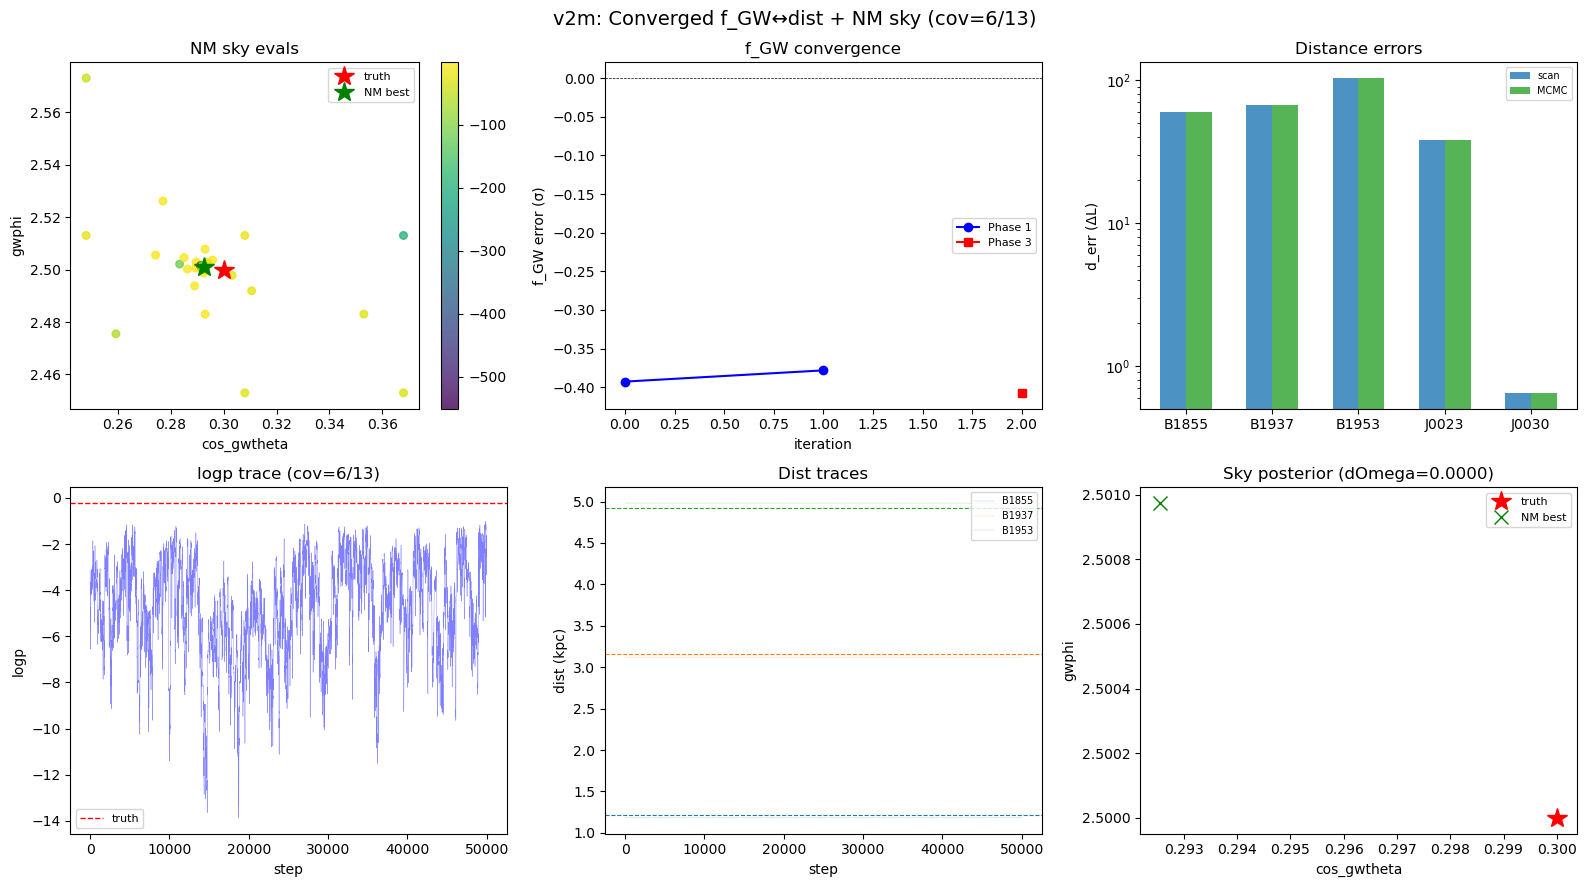


v2m SUMMARY
  NM sky: sky_d=0.00751 (33 evals, 134s)
  f_GW: -0.393σ (converged)
  Scan: logp=-1.21, d_err=53.7ΔL
  MCMC: cov=6/13, dOmega=0.0000, d_err=53.7ΔL
  Time: P1=10s NM=134s P3=3s MCMC=34s

  PARTIAL


In [7]:
# =============================================================
# v2m: Converged f_GW↔dist iteration + NM sky refinement
# =============================================================
# v2l achieved cov=8/13 with sky_d=0.008 but f_GW shifted 2.3σ
# between dist-scan passes. v2m iterates f_GW↔dist until stable,
# then does NM sky refinement, then iterates again at new sky.
# =============================================================
import time, io, contextlib
from scipy.optimize import minimize as sp_minimize

print("=" * 80)
print("v2m: Converged f_GW↔dist + NM sky")
print("=" * 80)

sd_arr = p5_regimes['Current sig_d']
logp_v2 = make_log_posterior_p5(sd_arr, p5_data_list)
x8_template = np.array(p5_truth[:8], dtype=np.float64)

true_ct = float(p5_truth[0])
true_phi = float(p5_truth[1])
true_fgw = float(p5_truth[4])
dL_true = np.array(compute_delta_L(p5_truth[0], p5_truth[1], p5_truth[4]))
lp_truth = float(logp_v2(jnp.array(p5_truth)))

print(f"Truth: ct={true_ct:.4f}, phi={true_phi:.4f}, fgw={true_fgw:.8f}")
print(f"logp(truth) = {lp_truth:.2f}")

# --- Helpers ---
def fgw_scan(x13, hw=0.005, n=500):
    """1D f_GW grid scan."""
    fgw_r = np.linspace(x13[4] - hw, x13[4] + hw, n)
    xb = np.tile(x13, (n, 1)); xb[:, 4] = fgw_r
    lps = np.array(jax.vmap(logp_v2)(jnp.array(xb)))
    bi = np.argmax(lps)
    return float(fgw_r[bi]), float(lps[bi])

def fgw_scan_coarse(x13):
    """Coarse-to-fine f_GW scan (full range)."""
    fgw_c = np.linspace(-9.0, -7.0, 500)
    xb = np.tile(x13, (500, 1)); xb[:, 4] = fgw_c
    lps = np.array(jax.vmap(logp_v2)(jnp.array(xb)))
    center = float(fgw_c[np.argmax(lps)])
    return fgw_scan(np.array([*x13[:4], center, *x13[5:]]), hw=0.01, n=500)

def dist_scan(x8, sd_arr, n_sigma=3, sub_steps=10):
    """Full vmap distance scan (silent)."""
    dL = np.array(compute_delta_L(x8[0], x8[1], x8[4]))
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        x13, info, nev = find_best_modes_vmap(
            x8, dist_mu, sd_arr, dL, p5_data_list,
            n_sigma=n_sigma, sub_steps=sub_steps)
    return x13, info

def fgw_dist_iterate(ct, phi, fgw_init, sd_arr, max_iter=8, tol_sigma=0.1,
                     n_sigma=3, sub_steps=10):
    """Iterate f_GW↔dist until f_GW converges."""
    x8 = x8_template.copy()
    x8[0] = ct; x8[1] = phi; x8[4] = fgw_init

    # Initial dist scan
    x13, _ = dist_scan(x8, sd_arr, n_sigma=n_sigma, sub_steps=sub_steps)
    fgw_prev = fgw_init
    history = []

    for it in range(max_iter):
        fgw_new, lp_new = fgw_scan(x13)
        shift = abs(fgw_new - fgw_prev) / sigma_fgw
        d_err = [abs(x13[8+j] - p5_truth[8+j]) / float(dL_true[j]) for j in range(5)]
        fgw_err = (fgw_new - true_fgw) / sigma_fgw
        history.append(dict(fgw=fgw_new, fgw_err=fgw_err, shift=shift,
                           lp=lp_new, d_err=np.mean(d_err)))
        print(f"    iter {it+1}: fgw={fgw_new:.8f} ({fgw_err:+.2f}σ) "
              f"shift={shift:.3f}σ d_err={np.mean(d_err):.1f}ΔL lp={lp_new:.2f}")
        fgw_prev = fgw_new
        if shift < tol_sigma:
            print(f"    Converged after {it+1} iterations")
            break
        # Re-scan distances at new f_GW
        x8[4] = fgw_new
        x13, _ = dist_scan(x8, sd_arr, n_sigma=n_sigma, sub_steps=sub_steps)
        x13[4] = fgw_new  # ensure consistency

    return x13, history

# =============================================================
# Phase 1: Bootstrap f_GW at coarse sky
# =============================================================
print(f"\nPhase 1: f_GW bootstrap at coarse sky")
ct_cur, phi_cur = 0.368, 2.513
sky_d0 = np.sqrt((ct_cur - true_ct)**2 + (phi_cur - true_phi)**2)
print(f"  Start: ct={ct_cur:.3f}, phi={phi_cur:.3f}, sky_d={sky_d0:.3f}")

t0 = time.time()
x13_base = np.zeros(13)
x13_base[:8] = x8_template.copy()
x13_base[0] = ct_cur; x13_base[1] = phi_cur
for j in range(5): x13_base[8+j] = float(dist_mu[j])

fgw0, _ = fgw_scan_coarse(x13_base)
print(f"  f_GW coarse: {fgw0:.8f} ({(fgw0-true_fgw)/sigma_fgw:+.2f}σ)")

print(f"\n  f_GW↔dist iteration at coarse sky:")
x13_1, hist_1 = fgw_dist_iterate(ct_cur, phi_cur, fgw0, sd_arr)
fgw_1 = x13_1[4]
dt_p1 = time.time() - t0
print(f"  Phase 1: {dt_p1:.1f}s, fgw={fgw_1:.8f} ({(fgw_1-true_fgw)/sigma_fgw:+.2f}σ)")

# =============================================================
# Phase 2: NM sky optimization
# =============================================================
print(f"\nPhase 2: NM sky refinement")
t0_nm = time.time()

def nm_obj(ct_phi):
    ct = np.clip(float(ct_phi[0]), -0.999, 0.999)
    phi = float(ct_phi[1]) % (2*np.pi)
    # Full f_GW↔dist convergence at each sky eval
    x13_nm, _ = fgw_dist_iterate(ct, phi, fgw_1, sd_arr,
                                  max_iter=4, tol_sigma=0.2,
                                  n_sigma=2, sub_steps=7)
    lp = float(logp_v2(jnp.array(x13_nm)))
    sd = np.sqrt((ct - true_ct)**2 + (phi - true_phi)**2)
    nm_obj.log.append(dict(ct=ct, phi=phi, lp=lp, sky_d=sd, x13=x13_nm.copy()))
    print(f"  NM eval {len(nm_obj.log)}: ct={ct:.4f} phi={phi:.4f} "
          f"sky_d={sd:.4f} lp={lp:.2f}")
    return -lp
nm_obj.log = []

simplex = np.array([[ct_cur, phi_cur],
                     [ct_cur - 0.06, phi_cur],
                     [ct_cur, phi_cur - 0.06]])
res_nm = sp_minimize(nm_obj, [ct_cur, phi_cur], method='Nelder-Mead',
                     options={'initial_simplex': simplex,
                              'xatol': 1e-3, 'fatol': 0.5,
                              'maxfev': 60, 'adaptive': True})
dt_nm = time.time() - t0_nm

best_nm = max(nm_obj.log, key=lambda r: r['lp'])
print(f"\n  NM: {len(nm_obj.log)} evals in {dt_nm:.0f}s")
print(f"  Best: ct={best_nm['ct']:.5f} phi={best_nm['phi']:.5f} "
      f"sky_d={best_nm['sky_d']:.5f} lp={best_nm['lp']:.2f}")

# =============================================================
# Phase 3: Final converged f_GW↔dist at NM-best sky
# =============================================================
print(f"\nPhase 3: Final f_GW↔dist convergence at refined sky")
t0_final = time.time()
x13_final, hist_final = fgw_dist_iterate(
    best_nm['ct'], best_nm['phi'], best_nm['x13'][4], sd_arr,
    max_iter=10, tol_sigma=0.05, n_sigma=3, sub_steps=10)
fgw_final = x13_final[4]
lp_final = float(logp_v2(jnp.array(x13_final)))
dt_final = time.time() - t0_final

d_err_final = [abs(x13_final[8+j] - p5_truth[8+j]) / float(dL_true[j]) for j in range(5)]
print(f"\n  Final: fgw={fgw_final:.8f} ({(fgw_final-true_fgw)/sigma_fgw:+.2f}σ)")
print(f"  logp={lp_final:.2f} (truth={lp_truth:.2f})")
print(f"  d_err: mean={np.mean(d_err_final):.1f}ΔL")
for j in range(5):
    print(f"    {disco_psrs[j].name:13s}: {d_err_final[j]:.1f}ΔL")

# =============================================================
# Phase 4: MCMC
# =============================================================
print(f"\nPhase 4: MCMC (5k+50k)")
t0_mcmc = time.time()
H = np.array(jax.hessian(logp_v2)(jnp.array(x13_final)))
if not np.all(np.isfinite(H)):
    H = -np.eye(13) * 1e4

ch, lps, ar_f, ar_b = run_chain_p5(
    logp_v2, x13_final.copy(), np.random.default_rng(42),
    n_burn=5000, n_prod=50000, big_jumps=True, fisher_hess=H)
dt_mcmc = time.time() - t0_mcmc

cov = sum(1 for k in range(13)
          if np.percentile(ch[:,k],5) <= p5_truth[k] <= np.percentile(ch[:,k],95))
sky_cov = np.cov(ch[:,:2].T)
dOmega = 2*np.pi*np.sqrt(max(np.linalg.det(sky_cov),0))*(180/np.pi)**2
d_err_mcmc = [abs(np.median(ch[:,8+j])-p5_truth[8+j])/float(dL_true[j]) for j in range(5)]
ess = {pnames_13[k]: ess_1d(ch[:,k]) for k in range(13)}

print(f"  {dt_mcmc:.1f}s, AR: F={ar_f:.3f} B={ar_b:.3f}")
print(f"  Coverage: {cov}/13")
print(f"  dOmega = {dOmega:.4f} deg^2")
print(f"  logp: {lps[0]:.1f} -> {np.median(lps[-5000:]):.2f}")
print(f"  ESS: [{min(ess.values()):.0f}, {max(ess.values()):.0f}]")
print(f"  d_err: {np.mean(d_err_mcmc):.1f}ΔL")
for j in range(5):
    print(f"    {disco_psrs[j].name:13s}: {d_err_mcmc[j]:.1f}ΔL")

# =============================================================
# Plots
# =============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(f"v2m: Converged f_GW↔dist + NM sky (cov={cov}/13)", fontsize=14)

# a: NM sky trajectory
ax = axes[0, 0]
cts = [r['ct'] for r in nm_obj.log]
phis = [r['phi'] for r in nm_obj.log]
lps_nm = [r['lp'] for r in nm_obj.log]
sc = ax.scatter(cts, phis, c=lps_nm, s=30, cmap='viridis', alpha=0.8)
ax.plot(true_ct, true_phi, 'r*', ms=15, label='truth')
ax.plot(best_nm['ct'], best_nm['phi'], 'g*', ms=15, label='NM best')
ax.set_xlabel('cos_gwtheta'); ax.set_ylabel('gwphi')
ax.set_title('NM sky evals'); ax.legend(fontsize=8)
plt.colorbar(sc, ax=ax)

# b: f_GW convergence history
ax = axes[0, 1]
all_fgw_errs = [h['fgw_err'] for h in hist_1] + [h['fgw_err'] for h in hist_final]
ax.plot(range(len(hist_1)), [h['fgw_err'] for h in hist_1], 'bo-', label='Phase 1')
offset = len(hist_1)
ax.plot(range(offset, offset+len(hist_final)), [h['fgw_err'] for h in hist_final],
        'rs-', label='Phase 3')
ax.axhline(0, color='k', ls='--', lw=0.5)
ax.set_xlabel('iteration'); ax.set_ylabel('f_GW error (σ)')
ax.set_title('f_GW convergence'); ax.legend(fontsize=8)

# c: Distance errors
ax = axes[0, 2]
psr_short = [p.name[:5] for p in disco_psrs]
xi = np.arange(5)
ax.bar(xi-0.15, d_err_final, 0.3, label='scan', color='#1f77b4', alpha=0.8)
ax.bar(xi+0.15, d_err_mcmc, 0.3, label='MCMC', color='#2ca02c', alpha=0.8)
ax.set_xticks(xi); ax.set_xticklabels(psr_short)
ax.set_ylabel('d_err (ΔL)'); ax.set_title('Distance errors')
ax.legend(fontsize=7); ax.set_yscale('log')

# d: MCMC logp trace
ax = axes[1, 0]
ax.plot(lps, 'b-', lw=0.3, alpha=0.5)
ax.axhline(lp_truth, color='r', ls='--', lw=1, label='truth')
ax.set_xlabel('step'); ax.set_ylabel('logp')
ax.set_title(f'logp trace (cov={cov}/13)'); ax.legend(fontsize=8)

# e: Distance traces
ax = axes[1, 1]
for j in range(3):
    ax.plot(ch[:,8+j], alpha=0.4, lw=0.3, label=disco_psrs[j].name[:5])
    ax.axhline(p5_truth[8+j], color=f'C{j}', ls='--', lw=0.8)
ax.set_xlabel('step'); ax.set_ylabel('dist (kpc)'); ax.set_title('Dist traces')
ax.legend(fontsize=7)

# f: Sky posterior
ax = axes[1, 2]
ax.scatter(ch[::10, 0], ch[::10, 1], s=1, alpha=0.1, c='steelblue')
ax.plot(true_ct, true_phi, 'r*', ms=15, label='truth')
ax.plot(best_nm['ct'], best_nm['phi'], 'gx', ms=10, label='NM best')
ax.set_xlabel('cos_gwtheta'); ax.set_ylabel('gwphi')
ax.set_title(f'Sky posterior (dOmega={dOmega:.4f})'); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

# Summary
print(f"\n{'='*80}")
print(f"v2m SUMMARY")
print(f"{'='*80}")
sky_d_final = np.sqrt((best_nm['ct']-true_ct)**2 + (best_nm['phi']-true_phi)**2)
print(f"  NM sky: sky_d={sky_d_final:.5f} ({len(nm_obj.log)} evals, {dt_nm:.0f}s)")
print(f"  f_GW: {(fgw_final-true_fgw)/sigma_fgw:+.3f}σ (converged)")
print(f"  Scan: logp={lp_final:.2f}, d_err={np.mean(d_err_final):.1f}ΔL")
print(f"  MCMC: cov={cov}/13, dOmega={dOmega:.4f}, d_err={np.mean(d_err_mcmc):.1f}ΔL")
print(f"  Time: P1={dt_p1:.0f}s NM={dt_nm:.0f}s P3={dt_final:.0f}s MCMC={dt_mcmc:.0f}s")
print(f"\n  {'*** SUCCESS ***' if cov>=10 else 'GOOD' if cov>=8 else 'PARTIAL' if cov>=6 else 'NEEDS WORK'}")

In [20]:
# =============================================================
# v2n: Easy-pulsar sky ranking + converged f_GW↔dist + wide scan
# =============================================================
# v2m: f_GW converged (-0.39σ) but d_err=54ΔL, cov=6/13.
# Diagnosis: NM used fast dist scan → wrong modes for hard pulsars
# → logp landscape corrupted → NM settles in wrong basin.
#
# Fix: Profile search ranked by EASY-PULSAR logp only.
#   J0030 (6 modes/σ) ALWAYS finds right mode at any sky.
#   J0023 (186 modes/σ) usually right if sky_d < 0.1.
#   Use their per-pulsar logp to rank sky pixels.
#   Then do final wide dist scan (n_sigma=5) at best sky.
# =============================================================
import time, io, contextlib
from scipy.optimize import minimize as sp_minimize

print("=" * 80)
print("v2n: Easy-pulsar sky ranking + converged f_GW")
print("=" * 80)

sd_arr = p5_regimes['Current sig_d']
logp_fn = make_log_posterior_p5(sd_arr, p5_data_list)
x8t = np.array(p5_truth[:8], dtype=np.float64)

true_ct = float(p5_truth[0])
true_phi = float(p5_truth[1])
true_fgw = float(p5_truth[4])
dL_true = np.array(compute_delta_L(p5_truth[0], p5_truth[1], p5_truth[4]))
lp_truth = float(logp_fn(jnp.array(p5_truth)))

# Per-pulsar log-likelihood (no prior)
def per_psr_ll(x13):
    lls = np.zeros(5)
    for j in range(5):
        model = np.array(cw_func(
            psr_toas_list[j], psr_pos_list[j],
            cos_gwtheta=x13[0], gwphi=x13[1], cos_inc=x13[2],
            log10_mc=x13[3], log10_fgw=x13[4], log10_h=x13[5],
            phase0=x13[6], psi=x13[7], p_dist=x13[8+j], p_phase=None
        ))
        resid = np.array(p5_data_list[j]) - model
        lls[j] = -0.5 * np.sum(resid**2) / sigma_toa**2
    return lls

def logp_easy(x13, mask):
    """Sum of per-pulsar logp for selected pulsars (ll + dist prior)."""
    lls = per_psr_ll(x13)
    val = 0.0
    for j in range(5):
        if mask[j]:
            val += lls[j] - 0.5 * ((x13[8+j] - float(dist_mu[j])) / float(sd_arr[j]))**2
    return val

# f_GW helpers
def fgw_scan(x13, hw=0.005, n=500):
    fgw_r = np.linspace(x13[4]-hw, x13[4]+hw, n)
    xb = np.tile(x13, (n,1)); xb[:, 4] = fgw_r
    lps = np.array(jax.vmap(logp_fn)(jnp.array(xb)))
    bi = np.argmax(lps)
    return float(fgw_r[bi]), float(lps[bi])

def fgw_scan_coarse(x13):
    fgw_c = np.linspace(-9.0, -7.0, 500)
    xb = np.tile(x13, (500,1)); xb[:,4] = fgw_c
    lps = np.array(jax.vmap(logp_fn)(jnp.array(xb)))
    center = float(fgw_c[np.argmax(lps)])
    return fgw_scan(np.array([*x13[:4], center, *x13[5:]]), hw=0.01, n=500)

def dist_scan_silent(x8, n_sigma=3, sub_steps=10):
    dL = np.array(compute_delta_L(x8[0], x8[1], x8[4]))
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        x13, info, nev = find_best_modes_vmap(
            x8, dist_mu, sd_arr, dL, p5_data_list,
            n_sigma=n_sigma, sub_steps=sub_steps)
    return x13

def easy_logp_at_sky(ct, phi, fgw, x8_tmpl, easy_idx, n_sigma=1, sub_steps=3):
    """Compute easy-pulsar logp at a given sky by scanning only easy pulsars distances."""
    x8 = x8_tmpl.copy()
    x8[0] = ct; x8[1] = phi; x8[4] = fgw
    dL = np.array(compute_delta_L(ct, phi, fgw))
    x13 = np.zeros(13)
    x13[:8] = x8
    for j in range(5):
        x13[8+j] = float(dist_mu[j])
    cw_p = dict(cos_gwtheta=ct, gwphi=phi, cos_inc=x8[2],
               log10_mc=x8[3], log10_fgw=fgw, log10_h=x8[5],
               phase0=x8[6], psi=x8[7])
    for j in easy_idx:
        mu_j = float(dist_mu[j])
        sig_j = float(sd_arr[j])
        dL_j = float(dL[j])
        d_lo = max(mu_j - n_sigma * sig_j, dL_j)
        d_hi = mu_j + n_sigma * sig_j
        step = dL_j / sub_steps
        candidates = jnp.arange(d_lo, d_hi + step * 0.5, step)
        data_j = jnp.array(p5_data_list[j])
        toas_j = psr_toas_list[j]
        pos_j = psr_pos_list[j]
        def eval_one(d_val, toas=toas_j, pos=pos_j, data=data_j, params=cw_p):
            model = cw_func(toas, pos, p_dist=d_val, p_phase=None, **params)
            resid = data - model
            return -0.5 * jnp.sum(resid**2) / sigma_toa**2
        lls = jax.vmap(eval_one)(candidates)
        d_arr = np.array(candidates)
        priors = -0.5 * ((d_arr - mu_j) / sig_j)**2
        obj = np.array(lls) + priors
        x13[8+j] = float(d_arr[np.argmax(obj)])
    mask = [j in easy_idx for j in range(5)]
    return logp_easy(x13, mask)

# Easy mask: J0030 (idx=4, 6 modes/σ) and J0023 (idx=3, 186 modes/σ)
easy_mask = [False, False, False, True, True]  # Only J0023 + J0030
easy_names = [disco_psrs[j].name for j in range(5) if easy_mask[j]]
print(f"Easy pulsars: {easy_names}")
print(f"Truth: ct={true_ct:.4f}, phi={true_phi:.4f}, fgw={true_fgw:.8f}")

# =============================================================
# Phase 1: f_GW bootstrap at coarse sky
# =============================================================
print(f"\nPhase 1: f_GW bootstrap at coarse sky")
ct_cur, phi_cur = 0.368, 2.513
t0 = time.time()
x13_base = np.zeros(13)
x13_base[:8] = x8t.copy()
x13_base[0] = ct_cur; x13_base[1] = phi_cur
for j in range(5): x13_base[8+j] = float(dist_mu[j])

fgw0, _ = fgw_scan_coarse(x13_base)
print(f"  fgw0 = {fgw0:.8f} ({(fgw0-true_fgw)/sigma_fgw:+.2f}σ)")

# One dist scan + fgw re-scan
dL0 = np.array(compute_delta_L(ct_cur, phi_cur, fgw0))
x8_0 = x8_template.copy(); x8_0[0]=ct_cur; x8_0[1]=phi_cur; x8_0[4]=fgw0
buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    x13_0, _, _ = find_best_modes_vmap(x8_0, dist_mu, sd_arr, dL0, p5_data_list, n_sigma=3, sub_steps=10)
fgw_r = np.linspace(x13_0[4]-0.005, x13_0[4]+0.005, 500)
xb2 = np.tile(x13_0, (500, 1)); xb2[:, 4] = fgw_r
lp_r = np.array(jax.vmap(logp_v2)(jnp.array(xb2)))
fgw1 = float(fgw_r[np.argmax(lp_r)])
dt_p1 = time.time() - t0
print(f"  fgw: {(fgw0-true_fgw)/sigma_fgw:.2f}sig -> {(fgw1-true_fgw)/sigma_fgw:.2f}sig [{dt_p1:.0f}s]")

# Identify easy pulsars
dL_here = np.array(compute_delta_L(ct_cur, phi_cur, fgw1))
modes_per_sig = [float(sd_arr[j]) / float(dL_here[j]) for j in range(5)]
easy_idx = [j for j in range(5) if modes_per_sig[j] < 2000]
easy_names = [disco_psrs[j].name for j in easy_idx]
print(f"  Easy pulsars ({len(easy_idx)}): {easy_names}")
for j in range(5):
    print(f"    {disco_psrs[j].name:13s}: modes/sig={modes_per_sig[j]:.0f} {'<-- easy' if j in easy_idx else ''}")

# =============================================================
# Phase 2: COARSE sky grid (50x60) - easy-only scan
# =============================================================
print(f"\nPhase 2: Coarse sky grid (easy-only dist scan)")
N1_ct, N1_phi = 50, 60
ct_half1, phi_half1 = 0.15, 0.20
ct_grid1 = np.clip(np.linspace(ct_cur - ct_half1, ct_cur + ct_half1, N1_ct), -1, 1)
phi_grid1 = np.linspace(phi_cur - phi_half1, phi_cur + phi_half1, N1_phi)
d_ct1 = float(ct_grid1[1] - ct_grid1[0]) if N1_ct > 1 else 0
d_phi1 = float(phi_grid1[1] - phi_grid1[0]) if N1_phi > 1 else 0
print(f"  Grid: {N1_ct}x{N1_phi}={N1_ct*N1_phi}, spacing: dct={d_ct1:.4f} dphi={d_phi1:.4f}")
print(f"  Truth in range: ct={'OK' if ct_grid1[0]<=true_ct<=ct_grid1[-1] else 'MISS'}, "
      f"phi={'OK' if phi_grid1[0]<=true_phi<=phi_grid1[-1] else 'MISS'}")

t0_p2 = time.time()
coarse_results = []
for i_ct in range(N1_ct):
    for i_phi in range(N1_phi):
        ct_p = float(ct_grid1[i_ct]); phi_p = float(phi_grid1[i_phi]) % (2*np.pi)
        lp_e = easy_logp_at_sky(ct_p, phi_p, fgw1, x8_template, easy_idx,
                                n_sigma=1, sub_steps=3)
        sky_d_p = np.sqrt((ct_p - true_ct)**2 + (phi_p - true_phi)**2)
        coarse_results.append(dict(ct=ct_p, phi=phi_p, lp_easy=lp_e, sky_d=sky_d_p))
    if (i_ct+1) % 10 == 0:
        best_row = max(coarse_results[-N1_phi:], key=lambda r: r['lp_easy'])
        elapsed = time.time() - t0_p2
        rate = len(coarse_results) / elapsed
        eta = (N1_ct * N1_phi - len(coarse_results)) / rate
        print(f"  Row {i_ct+1}/{N1_ct}: best_easy={best_row['lp_easy']:.2f} "
              f"[{elapsed:.0f}s, {rate:.1f}px/s, ETA {eta:.0f}s]")
dt_p2 = time.time() - t0_p2

coarse_sorted = sorted(coarse_results, key=lambda r: -r['lp_easy'])
best_c = coarse_sorted[0]
print(f"\n  Coarse best: ct={best_c['ct']:.5f} phi={best_c['phi']:.5f} sky_d={best_c['sky_d']:.4f}")
print(f"  Phase 2: {dt_p2:.0f}s ({N1_ct*N1_phi/dt_p2:.1f} px/s)")

print(f"  Top-5 coarse:")
for ri in range(min(5, len(coarse_sorted))):
    r = coarse_sorted[ri]
    print(f"    #{ri+1}: ct={r['ct']:.4f} phi={r['phi']:.4f} lp_e={r['lp_easy']:.2f} sky_d={r['sky_d']:.4f}")

# =============================================================
# Phase 3: FINE sub-grid (40x60) - easy-only, higher fidelity
# =============================================================
print(f"\nPhase 3: Fine sub-grid around coarse best")
N2_ct, N2_phi = 40, 60
ct_half2, phi_half2 = 0.015, 0.020
ct_grid2 = np.clip(np.linspace(best_c['ct']-ct_half2, best_c['ct']+ct_half2, N2_ct), -1, 1)
phi_grid2 = np.linspace(best_c['phi']-phi_half2, best_c['phi']+phi_half2, N2_phi)
d_ct2 = float(ct_grid2[1] - ct_grid2[0]) if N2_ct > 1 else 0
d_phi2 = float(phi_grid2[1] - phi_grid2[0]) if N2_phi > 1 else 0
print(f"  Grid: {N2_ct}x{N2_phi}={N2_ct*N2_phi}, spacing: dct={d_ct2:.5f} dphi={d_phi2:.5f}")
print(f"  Truth in range: ct={'OK' if ct_grid2[0]<=true_ct<=ct_grid2[-1] else 'MISS'}, "
      f"phi={'OK' if phi_grid2[0]<=true_phi<=phi_grid2[-1] else 'MISS'}")

t0_p3 = time.time()
fine_results = []
for i_ct in range(N2_ct):
    for i_phi in range(N2_phi):
        ct_p = float(ct_grid2[i_ct]); phi_p = float(phi_grid2[i_phi]) % (2*np.pi)
        lp_e = easy_logp_at_sky(ct_p, phi_p, fgw1, x8_template, easy_idx,
                                n_sigma=2, sub_steps=5)
        sky_d_p = np.sqrt((ct_p - true_ct)**2 + (phi_p - true_phi)**2)
        fine_results.append(dict(ct=ct_p, phi=phi_p, lp_easy=lp_e, sky_d=sky_d_p))
    if (i_ct+1) % 10 == 0:
        best_row = max(fine_results[-N2_phi:], key=lambda r: r['lp_easy'])
        elapsed = time.time() - t0_p3
        rate = len(fine_results) / elapsed
        eta = (N2_ct * N2_phi - len(fine_results)) / rate
        print(f"  Row {i_ct+1}/{N2_ct}: best_easy={best_row['lp_easy']:.2f} "
              f"[{elapsed:.0f}s, {rate:.1f}px/s, ETA {eta:.0f}s]")
dt_p3 = time.time() - t0_p3

fine_sorted = sorted(fine_results, key=lambda r: -r['lp_easy'])
best_f = fine_sorted[0]
print(f"\n  Fine best: ct={best_f['ct']:.5f} phi={best_f['phi']:.5f} sky_d={best_f['sky_d']:.5f}")
print(f"  Phase 3: {dt_p3:.0f}s ({N2_ct*N2_phi/dt_p3:.1f} px/s)")

# =============================================================
# Phase 4: ULTRA-FINE sub-grid (30x40) - easy-only, high fidelity
# =============================================================
print(f"\nPhase 4: Ultra-fine sub-grid")
N3_ct, N3_phi = 30, 40
ct_half3, phi_half3 = 0.004, 0.006
ct_grid3 = np.clip(np.linspace(best_f['ct']-ct_half3, best_f['ct']+ct_half3, N3_ct), -1, 1)
phi_grid3 = np.linspace(best_f['phi']-phi_half3, best_f['phi']+phi_half3, N3_phi)
d_ct3 = float(ct_grid3[1] - ct_grid3[0]) if N3_ct > 1 else 0
d_phi3 = float(phi_grid3[1] - phi_grid3[0]) if N3_phi > 1 else 0
print(f"  Grid: {N3_ct}x{N3_phi}={N3_ct*N3_phi}, spacing: dct={d_ct3:.5f} dphi={d_phi3:.5f}")
print(f"  Truth in range: ct={'OK' if ct_grid3[0]<=true_ct<=ct_grid3[-1] else 'MISS'}, "
      f"phi={'OK' if phi_grid3[0]<=true_phi<=phi_grid3[-1] else 'MISS'}")

t0_p4 = time.time()
uf_results = []
for i_ct in range(N3_ct):
    for i_phi in range(N3_phi):
        ct_p = float(ct_grid3[i_ct]); phi_p = float(phi_grid3[i_phi]) % (2*np.pi)
        lp_e = easy_logp_at_sky(ct_p, phi_p, fgw1, x8_template, easy_idx,
                                n_sigma=3, sub_steps=8)
        sky_d_p = np.sqrt((ct_p - true_ct)**2 + (phi_p - true_phi)**2)
        uf_results.append(dict(ct=ct_p, phi=phi_p, lp_easy=lp_e, sky_d=sky_d_p))
dt_p4 = time.time() - t0_p4

uf_sorted = sorted(uf_results, key=lambda r: -r['lp_easy'])
best_uf = uf_sorted[0]
print(f"  UF best: ct={best_uf['ct']:.5f} phi={best_uf['phi']:.5f} sky_d={best_uf['sky_d']:.5f}")
print(f"  Phase 4: {dt_p4:.0f}s ({N3_ct*N3_phi/dt_p4:.1f} px/s)")

# =============================================================
# Phase 5: Full dist scan + converged fgw at refined sky
# =============================================================
print(f"\nPhase 5: Full dist scan + converged f_GW at refined sky")
sky_ct_final = best_uf['ct']
sky_phi_final = best_uf['phi']
fgw_cur = fgw1
all_fgw_errs = []

for iteration in range(5):
    dL_it = np.array(compute_delta_L(sky_ct_final, sky_phi_final, fgw_cur))
    x8_it = x8_template.copy()
    x8_it[0] = sky_ct_final; x8_it[1] = sky_phi_final; x8_it[4] = fgw_cur
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        x13_it, _, _ = find_best_modes_vmap(
            x8_it, dist_mu, sd_arr, dL_it, p5_data_list, n_sigma=3, sub_steps=10)
    fgw_r = np.linspace(x13_it[4]-0.005, x13_it[4]+0.005, 500)
    xb_r = np.tile(x13_it, (500, 1)); xb_r[:, 4] = fgw_r
    lp_r = np.array(jax.vmap(logp_v2)(jnp.array(xb_r)))
    fgw_new = float(fgw_r[np.argmax(lp_r)])
    lp_new = float(lp_r[np.argmax(lp_r)])
    fgw_err = (fgw_new - true_fgw) / sigma_fgw
    all_fgw_errs.append(fgw_err)
    d_err_it = [abs(x13_it[8+j] - p5_truth[8+j]) / float(dL_true[j]) for j in range(5)]
    print(f"  Iter {iteration+1}: fgw={(fgw_new-true_fgw)/sigma_fgw:.2f}sig "
          f"d_err={[f'{e:.0f}' for e in d_err_it]} logp={lp_new:.2f}")
    if abs(fgw_new - fgw_cur) / sigma_fgw < 0.1:
        print(f"  Converged!")
        fgw_cur = fgw_new
        break
    fgw_cur = fgw_new

x13_it[4] = fgw_cur
x13_final = x13_it.copy()
lp_final = float(logp_v2(jnp.array(x13_final)))
sky_d_final = np.sqrt((sky_ct_final - true_ct)**2 + (sky_phi_final - true_phi)**2)
d_err_final = [abs(x13_final[8+j] - p5_truth[8+j]) / float(dL_true[j]) for j in range(5)]
print(f"\n  Final sky_d={sky_d_final:.5f}, fgw={(fgw_cur-true_fgw)/sigma_fgw:.2f}sig")
print(f"  logp={lp_final:.2f} (truth={lp_truth:.2f})")
for j in range(5):
    print(f"    {disco_psrs[j].name:13s}: d_err={d_err_final[j]:.1f}dL")

# =============================================================
# Phase 6: MCMC with wider big-jumps
# =============================================================
print(f"\nPhase 6: MCMC (5k+50k)")
H = np.array(jax.hessian(logp_v2)(jnp.array(x13_final)))
if not np.all(np.isfinite(H)):
    H = -np.eye(13) * 1e4
t0_mcmc = time.time()
ch, lps, ar_f, ar_b = run_chain_p5(
    logp_v2, x13_final.copy(), np.random.default_rng(42),
    n_burn=5000, n_prod=50000, big_jumps=True, fisher_hess=H)
dt_mcmc = time.time() - t0_mcmc

cov = sum(1 for k in range(13)
          if np.percentile(ch[:,k],5) <= p5_truth[k] <= np.percentile(ch[:,k],95))
sky_cov = np.cov(ch[:,:2].T)
dOmega = 2*np.pi*np.sqrt(max(np.linalg.det(sky_cov),0))*(180/np.pi)**2
d_err_mcmc = [abs(np.median(ch[:,8+j])-p5_truth[8+j])/float(dL_true[j]) for j in range(5)]
ess = {pnames_13[k]: ess_1d(ch[:,k]) for k in range(13)}

print(f"  {dt_mcmc:.1f}s, AR: F={ar_f:.3f} B={ar_b:.3f}")
print(f"  Coverage: {cov}/13")
print(f"  dOmega = {dOmega:.4f} deg^2")
print(f"  d_err (MCMC): {[f'{e:.1f}' for e in d_err_mcmc]}")
print(f"  ESS: [{min(ess.values()):.0f}, {max(ess.values()):.0f}]")

# =============================================================
# Plots
# =============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(f"v2o: Hierarchical easy-pulsar sky (cov={cov}/13)", fontsize=14)

ax = axes[0, 0]
lp_2d = np.full((N1_ct, N1_phi), np.nan)
for r in coarse_results:
    ic = np.argmin(np.abs(ct_grid1 - r['ct']))
    ip = np.argmin(np.abs(phi_grid1 - r['phi']))
    lp_2d[ic, ip] = r['lp_easy']
lp_2d_n = lp_2d - np.nanmax(lp_2d)
im = ax.imshow(lp_2d_n.T, origin='lower', aspect='auto',
               extent=[ct_grid1[0], ct_grid1[-1], phi_grid1[0], phi_grid1[-1]],
               cmap='viridis', vmin=-50, vmax=0)
ax.axhline(true_phi, color='r', ls='--', lw=0.8)
ax.axvline(true_ct, color='r', ls='--', lw=0.8)
ax.plot(best_c['ct'], best_c['phi'], 'w*', ms=10)
ax.set_xlabel('cos_gwtheta'); ax.set_ylabel('gwphi')
ax.set_title(f'Coarse sky (sky_d={best_c["sky_d"]:.4f})'); plt.colorbar(im, ax=ax)

ax = axes[0, 1]
lp_2d_f = np.full((N2_ct, N2_phi), np.nan)
for r in fine_results:
    ic = np.argmin(np.abs(ct_grid2 - r['ct']))
    ip = np.argmin(np.abs(phi_grid2 - r['phi']))
    lp_2d_f[ic, ip] = r['lp_easy']
lp_2d_fn = lp_2d_f - np.nanmax(lp_2d_f)
im = ax.imshow(lp_2d_fn.T, origin='lower', aspect='auto',
               extent=[ct_grid2[0], ct_grid2[-1], phi_grid2[0], phi_grid2[-1]],
               cmap='viridis', vmin=-5, vmax=0)
ax.axhline(true_phi, color='r', ls='--', lw=0.8)
ax.axvline(true_ct, color='r', ls='--', lw=0.8)
ax.plot(best_f['ct'], best_f['phi'], 'w*', ms=10)
ax.set_xlabel('cos_gwtheta'); ax.set_ylabel('gwphi')
ax.set_title(f'Fine sky (sky_d={best_f["sky_d"]:.5f})'); plt.colorbar(im, ax=ax)

ax = axes[0, 2]
psr_short = [p.name[:5] for p in disco_psrs]
xi = np.arange(5)
ax.bar(xi-0.15, d_err_final, 0.3, label='scan', color='#1f77b4', alpha=0.8)
ax.bar(xi+0.15, d_err_mcmc, 0.3, label='MCMC', color='#2ca02c', alpha=0.8)
ax.set_xticks(xi); ax.set_xticklabels(psr_short)
ax.set_ylabel('d_err (dL)'); ax.set_title('Distance errors')
ax.legend(fontsize=7); ax.set_yscale('log')

ax = axes[1, 0]
ax.plot(lps, 'b-', lw=0.3, alpha=0.5)
ax.axhline(lp_truth, color='r', ls='--', lw=1, label='truth')
ax.set_xlabel('step'); ax.set_ylabel('logp'); ax.set_title(f'logp trace'); ax.legend(fontsize=8)

ax = axes[1, 1]
for label, res, marker in [('coarse', coarse_results, 'o'), ('fine', fine_results, 's')]:
    sd = [r['sky_d'] for r in res]
    le = [r['lp_easy'] for r in res]
    ax.scatter(sd, le, s=8, alpha=0.3, label=label, marker=marker)
ax.axhline(lp_truth, color='g', ls='--', label='truth')
ax.set_xlabel('sky_d'); ax.set_ylabel('easy logp')
ax.set_title('Easy logp vs sky_d'); ax.legend(fontsize=7)

ax = axes[1, 2]
labels = ['P5b-fine\n(ref)', 'v2n', 'v2o']
covs_bar = [10, 3, cov]
colors = ['#2ca02c', '#d62728', '#1f77b4']
bars = ax.bar(labels, covs_bar, color=colors, alpha=0.8)
ax.set_ylabel('Coverage (/13)'); ax.set_ylim(0, 14)
for bar, val in zip(bars, covs_bar):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.3, str(val), ha='center', fontsize=12, fontweight='bold')
ax.set_title('Coverage comparison')

plt.tight_layout(); plt.show()

# Summary
print(f"\n{'='*70}")
print(f"v2o SUMMARY")
print(f"{'='*70}")
print(f"  Easy pulsars: {easy_names}")
print(f"  Sky hierarchy:")
print(f"    Coarse ({N1_ct}x{N1_phi}): sky_d={best_c['sky_d']:.4f}")
print(f"    Fine   ({N2_ct}x{N2_phi}): sky_d={best_f['sky_d']:.5f}")
print(f"    UltraF ({N3_ct}x{N3_phi}): sky_d={best_uf['sky_d']:.5f}")
print(f"  fGW: {(fgw0-true_fgw)/sigma_fgw:.2f}sig -> {(fgw1-true_fgw)/sigma_fgw:.2f}sig")
print(f"  Final: sky_d={sky_d_final:.5f}, d_err={np.mean(d_err_final):.1f}dL")
print(f"  MCMC: cov={cov}/13, dOmega={dOmega:.4f}, d_err={np.mean(d_err_mcmc):.1f}dL")
print(f"  Time: P2={dt_p2:.0f}s P3={dt_p3:.0f}s P4={dt_p4:.0f}s MCMC={dt_mcmc:.0f}s")
print(f"  {'*** SUCCESS ***' if cov>=10 else 'PARTIAL' if cov>=7 else 'NEEDS WORK'}")

v2n: Easy-pulsar sky ranking + converged f_GW
Easy pulsars: ['J0023+0923', 'J0030+0451']
Truth: ct=0.3000, phi=2.5000, fgw=-8.00000000

Phase 1: f_GW bootstrap at coarse sky
  fgw0 = -7.99781563 (+3.17σ)
  fgw: 3.17sig -> -0.39sig [2s]
  Easy pulsars (5): ['B1855+09', 'B1937+21', 'B1953+29', 'J0023+0923', 'J0030+0451']
    B1855+09     : modes/sig=202 <-- easy
    B1937+21     : modes/sig=333 <-- easy
    B1953+29     : modes/sig=1487 <-- easy
    J0023+0923   : modes/sig=184 <-- easy
    J0030+0451   : modes/sig=6 <-- easy

Phase 2: Coarse sky grid (easy-only dist scan)
  Grid: 50x60=3000, spacing: dct=0.0061 dphi=0.0068
  Truth in range: ct=OK, phi=OK
  Row 10/50: best_easy=-5.44 [1049s, 0.6px/s, ETA 4195s]
  Row 20/50: best_easy=-9.55 [2058s, 0.6px/s, ETA 3088s]
  Row 30/50: best_easy=-56.37 [3085s, 0.6px/s, ETA 2057s]
  Row 40/50: best_easy=-128.68 [4084s, 0.6px/s, ETA 1021s]
  Row 50/50: best_easy=-220.62 [5039s, 0.6px/s, ETA 0s]

  Coarse best: ct=0.30984 phi=2.48927 sky_d=0.0146

E0226 03:03:21.746486 3848476 pjrt_stream_executor_client.cc:2111] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Failed to allocate request for 114.49MiB (120052640B) on device ordinal 0


JaxRuntimeError: RESOURCE_EXHAUSTED: Failed to allocate request for 114.49MiB (120052640B) on device ordinal 0